
<div style="border:solid green 2px; padding: 20px">

👋 **Hello! I'm Dot, your AI reviewer.**

I've completed the first pass of your code review. Below, you'll find my comments and suggestions for improvement.

**What should you do next?**

1. **Review:** check my comments in the notebook below.
2. **Decide:**
* **Agree with the feedback?** Great! Update your code accordingly.
* **Disagree or think it's a mistake?** No problem! You can keep your code exactly as it is.


3. **Resubmit:** Send your project back. **Your next iteration will be reviewed by a human expert**, whether you made changes or not.

-------------------------------------------------------------------------------------------------------------
Please find my comments below—**I kindly ask that you do not move, modify, or delete them**.

You can find my comments highlighted in green, yellow, or red boxes like this:

<div class="alert alert-block alert-success">
<b>Reviewer's comment, Iteration X</b> <a class="tocSkip"></a>

Success. Everything is done succesfully.
</div>

<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration X</b> <a class="tocSkip"></a>

Remarks. Some recommendations.
</div>

<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration X</b> <a class="tocSkip"></a>

Needs fixing. The block requires some corrections.
</div>



<div style="border:solid green 2px; padding: 20px">
<b>Reviewer's comment v2:</b>

    
<b>Overall Feedback</b>
    
Hello Mohammad,

My name is **Gerardo Flores** and you can find me on the HUB as https://hub.tripleten.com/u/1949959f
    
You’ve submitted another project—great work! Your commitment to pushing through the challenges of this program is admirable.

After reviewing your submission, it is approved.
    
   
You can find my more detailed notes within your project notebook in the `Reviewer's comment v2:` section.


If you find yourself uncertain or in need of further insights, never hesitate to consult with your tutor or ask your questions here. We are here to guide and assist you.

# Video Game Sales Analysis Project
## Project Overview

In this project, you'll analyze video game sales data to identify patterns that determine a game's success. Working as an analyst for the online store Ice, you'll use this information to help plan future advertising campaigns.

## Environment Setup and Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings('ignore')
try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    plt.style.use('seaborn-whitegrid')
sns.set_palette('Set2')
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 140)

## Step 1: Loading and Initial Data Exploration

First, let's load our dataset and examine its basic properties:

In [2]:
df = pd.read_csv('/datasets/games.csv')
df.head()

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


In [3]:
print('Shape:', df.shape)
print()
df.info()

Shape: (16715, 11)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


In [4]:
print('Duplicate full rows:', df.duplicated().sum())
print('Duplicate (Name, Platform, Year_of_Release):', df.duplicated(subset=['Name','Platform','Year_of_Release']).sum())
df[df.duplicated(subset=['Name','Platform','Year_of_Release'], keep=False)].sort_values(['Name','Platform','Year_of_Release']).head(10)

Duplicate full rows: 0
Duplicate (Name, Platform, Year_of_Release): 2


,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
604,Madden NFL 13,PS3,2012.0,Sports,2.11,0.22,0.00,0.23,83.0,5.5,E
16230,Madden NFL 13,PS3,2012.0,Sports,0.00,0.01,0.00,0.00,83.0,5.5,E
659,NaN,GEN,1993.0,NaN,1.78,0.53,0.00,0.08,NaN,NaN,NaN
14244,NaN,GEN,1993.0,NaN,0.00,0.00,0.03,0.00,NaN,NaN,NaN


### Key Questions to Answer:
- What's the total number of records in our dataset?
- What data types are present in each column?
- Are there any obvious issues with the data?
- Do we see any immediate patterns or anomalies?

## Step 2: Data Preparation

### 2.1 Standardizing Column Names

In [5]:
df.columns = df.columns.str.lower()

In [6]:
df.columns.tolist()

['name',
 'platform',
 'year_of_release',
 'genre',
 'na_sales',
 'eu_sales',
 'jp_sales',
 'other_sales',
 'critic_score',
 'user_score',
 'rating']

<div class="alert alert-block alert-success">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Nice, well-structured start: you set up the environment cleanly, loaded the dataset, inspected it with head/shape/info, checked duplicates, and standardized column names as requested.

</div>


### 2.2 Data Type Conversion

In [7]:
df.dtypes

name                object
platform            object
year_of_release    float64
genre               object
na_sales           float64
eu_sales           float64
jp_sales           float64
other_sales        float64
critic_score       float64
user_score          object
rating              object
dtype: object

In [8]:
# year_of_release -> nullable Int64 (there are NaNs)
df['year_of_release'] = df['year_of_release'].astype('Int64')

# user_score is object because it contains the string 'tbd'; coerce to numeric
df['user_score'] = pd.to_numeric(df['user_score'], errors='coerce')

# critic_score is already float; keep
df['critic_score'] = pd.to_numeric(df['critic_score'], errors='coerce')

# Why:
# - year_of_release as Int64 preserves NaN while letting us treat years as integers
# - user_score had 'tbd' (to-be-determined) which prevented numeric conversion
# - all sales columns are already float and stay as float
df.dtypes

name                object
platform            object
year_of_release      Int64
genre               object
na_sales           float64
eu_sales           float64
jp_sales           float64
other_sales        float64
critic_score       float64
user_score         float64
rating              object
dtype: object

In [9]:
# 'tbd' means the user score had not yet been assigned when the data was collected.
# We treat 'tbd' as missing (NaN) because:
#   1. 'tbd' is not a valid numeric score, it is a placeholder
#   2. Keeping it as a string would block any numeric analysis on user_score
#   3. We cannot guess what the eventual score would be without inventing signal
# pd.to_numeric(errors='coerce') above converted every 'tbd' to NaN. Count below:
print('NaN user_score values after coercion:', df['user_score'].isna().sum())

NaN user_score values after coercion: 9125


### 2.3 Handling Missing Values

In [10]:
df.isna().sum()

name                  2
platform              0
year_of_release     269
genre                 2
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8578
user_score         9125
rating             6766
dtype: int64

In [11]:
(df.isna().sum() / len(df) * 100).round(2).sort_values(ascending=False)

user_score         54.59
critic_score       51.32
rating             40.48
year_of_release     1.61
name                0.01
genre               0.01
platform            0.00
na_sales            0.00
eu_sales            0.00
jp_sales            0.00
other_sales         0.00
dtype: float64

In [12]:
# How often are critic_score, user_score, and rating missing together?
both = df[['critic_score','user_score','rating']].isna()
print('Rows missing all three review fields:', both.all(axis=1).sum())
print('Rows missing none of the three:', (~both.any(axis=1)).sum())

print('\nMissing rate of critic_score by year:')
print(df.groupby('year_of_release')['critic_score'].apply(lambda s: s.isna().mean()).round(2))

Rows missing all three review fields: 6667
Rows missing none of the three: 6947

Missing rate of critic_score by year:
year_of_release
1980    1.00
1981    1.00
1982    1.00
1983    1.00
1984    1.00
1985    0.93
1986    1.00
1987    1.00
1988    0.93
1989    1.00
1990    1.00
1991    1.00
1992    0.98
1993    1.00
1994    0.99
1995    1.00
1996    0.97
1997    0.94
1998    0.93
1999    0.88
2000    0.59
2001    0.32
2002    0.24
2003    0.25
2004    0.26
2005    0.30
2006    0.38
2007    0.42
2008    0.50
2009    0.54
2010    0.60
2011    0.56
2012    0.51
2013    0.50
2014    0.55
2015    0.63
2016    0.54
Name: critic_score, dtype: float64


In [13]:
# Strategy:
# - name / genre: 2 rows missing each, cannot be imputed -> drop
# - year_of_release: leave as <NA>; we filter rows that need a year later
# - critic_score / user_score: leave as NaN (do not impute review scores)
# - rating: leave as NaN; treat "no rating" as its own category

df = df.dropna(subset=['name','genre']).reset_index(drop=True)
print('Shape after dropping rows with no name/genre:', df.shape)
print()
print(df.isna().sum())

Shape after dropping rows with no name/genre: (16713, 11)

name                  0
platform              0
year_of_release     269
genre                 0
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8576
user_score         9123
rating             6764
dtype: int64


<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Your missing-values strategy mentions treating missing `rating` as its own category, but the code still leaves `rating` as NaN. Since `groupby('rating')` will drop NaNs, later analyses won’t include the “no rating/unknown” segment, which conflicts with your stated approach—consider explicitly labeling missing ratings before running rating-based aggregations.

</div>


<div class="alert alert-block alert-success">
<b>Reviewer's comment v2</b>

Well done!

In [14]:
# Why are values missing?
# - critic_score / user_score: many older releases, niche or shovelware titles
#   were never professionally reviewed. Metacritic only covers a portion of the
#   market and started later in time.
# - rating: the ESRB is a North American body; titles released only in Japan
#   or Europe, or released before the ESRB existed (pre-1994), have no rating.
# - year_of_release: a small number of records have no year - likely data entry
#   omissions.
#
# Why I did NOT impute critic_score, user_score, or rating:
#   imputing review scores would invent signal that was not there. Many of the
#   downstream analyses (e.g. score vs sales correlation, ESRB impact) would be
#   distorted by fake scores. Better to let analyses that need these columns
#   drop the rows where they are missing.

print('Final missing counts:')
print(df.isna().sum())

Final missing counts:
name                  0
platform              0
year_of_release     269
genre                 0
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8576
user_score         9123
rating             6764
dtype: int64


### 2.4 Calculate Total Sales

In [15]:
df['total_sales'] = df[['na_sales','eu_sales','jp_sales','other_sales']].sum(axis=1)
df[['name','platform','year_of_release','na_sales','eu_sales','jp_sales','other_sales','total_sales']].head()

,name,platform,year_of_release,na_sales,eu_sales,jp_sales,other_sales,total_sales
0,Wii Sports,Wii,2006,41.36,28.96,3.77,8.45,82.54
1,Super Mario Bros.,NES,1985,29.08,3.58,6.81,0.77,40.24
2,Mario Kart Wii,Wii,2008,15.68,12.76,3.79,3.29,35.52
3,Wii Sports Resort,Wii,2009,15.61,10.93,3.28,2.95,32.77
4,Pokemon Red/Pokemon Blue,GB,1996,11.27,8.89,10.22,1.00,31.38


# Step 3: Analyzing Video Game Sales Data

## 3.1 Temporal Analysis of Game Releases
Let's first examine the distribution of game releases across different years to understand our data's coverage and significance:

In [16]:
releases_per_year = df.groupby('year_of_release').size().reset_index(name='num_releases')
releases_per_year

,year_of_release,num_releases
0,1980,9
1,1981,46
2,1982,36
3,1983,17
4,1984,14
5,1985,14
6,1986,21
7,1987,16
8,1988,15
9,1989,17


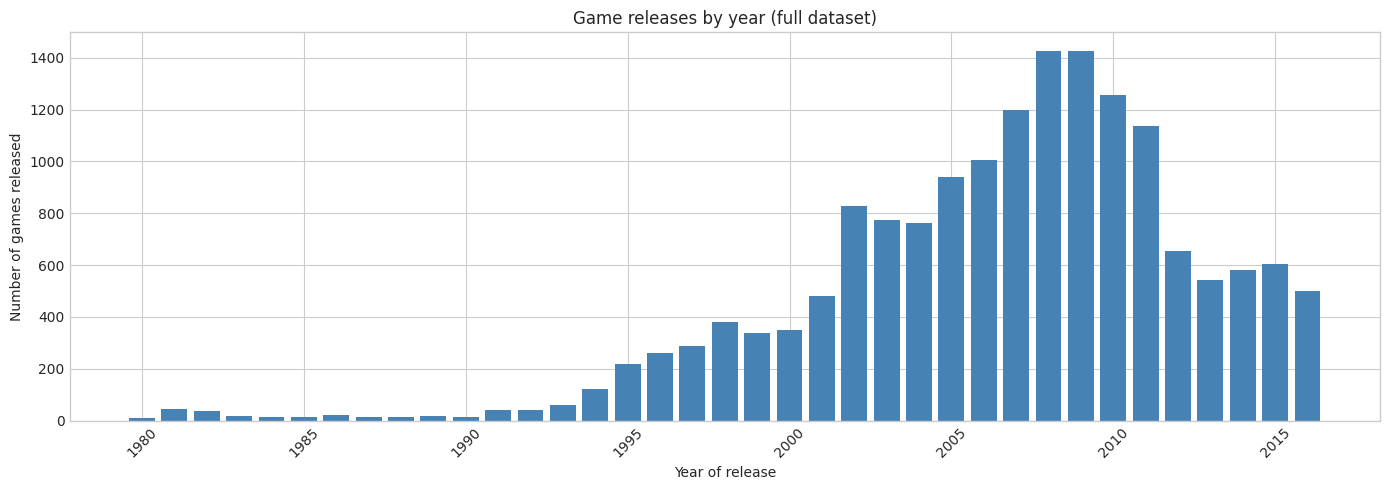

In [17]:
plt.figure(figsize=(14, 5))
plt.bar(releases_per_year['year_of_release'].astype('Int64').astype(int),
        releases_per_year['num_releases'], color='steelblue')
plt.xlabel('Year of release')
plt.ylabel('Number of games released')
plt.title('Game releases by year (full dataset)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [18]:
yearly_stats = df.groupby('year_of_release').agg(
    num_releases=('name','count'),
    total_sales=('total_sales','sum'),
    avg_sales=('total_sales','mean'),
    median_sales=('total_sales','median')
).round(3)
yearly_stats

,num_releases,total_sales,avg_sales,median_sales
year_of_release,,,,
1980,9,11.38,1.264,0.770
1981,46,35.68,0.776,0.465
1982,36,28.88,0.802,0.540
1983,17,16.80,0.988,0.770
1984,14,50.35,3.596,1.485
1985,14,53.95,3.854,1.015
1986,21,37.08,1.766,1.360
1987,16,21.70,1.356,0.885
1988,15,47.21,3.147,1.510


### Questions to Consider:
- Which years show significant numbers of game releases?
- Are there any notable trends or patterns in the number of releases?
- Is there enough recent data to make predictions for 2017?

<div class="alert alert-block alert-success">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Good work in the time-based analysis: you computed releases by year, visualized the distribution, and added helpful yearly summary stats using the `total_sales` column.

</div>


## 3.2 Platform Sales Analysis Over Time

Now let's analyze how sales vary across platforms and years:

In [19]:
platform_year_sales = df.groupby(['platform','year_of_release'])['total_sales'].sum().reset_index()
platform_year_sales.head()

,platform,year_of_release,total_sales
0,2600,1980,11.38
1,2600,1981,35.68
2,2600,1982,28.88
3,2600,1983,5.84
4,2600,1984,0.27


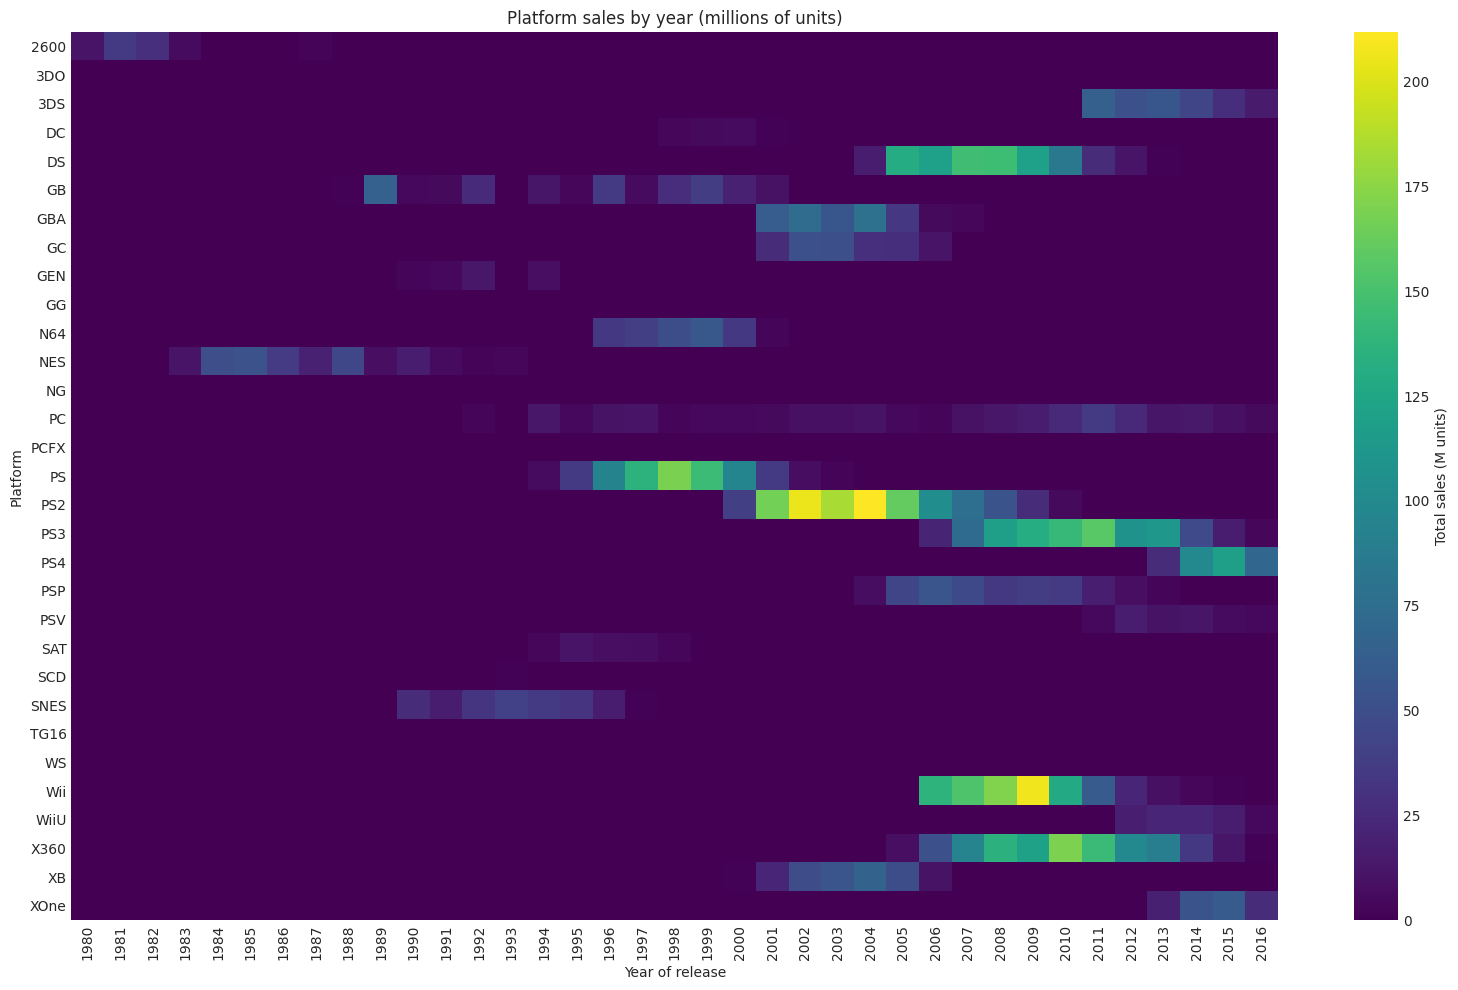

In [20]:
pivot = df.pivot_table(index='platform', columns='year_of_release',
                      values='total_sales', aggfunc='sum').fillna(0)
plt.figure(figsize=(16, 10))
sns.heatmap(pivot, cmap='viridis', cbar_kws={'label':'Total sales (M units)'})
plt.title('Platform sales by year (millions of units)')
plt.xlabel('Year of release')
plt.ylabel('Platform')
plt.tight_layout()
plt.show()

In [21]:
# Platforms with the largest drop in sales over the most recent 4 recorded years
recent_years = [int(y) for y in sorted(df['year_of_release'].dropna().unique())[-4:]]
print('Recent years analyzed:', recent_years)
recent = df[df['year_of_release'].isin(recent_years)]
platform_trend = recent.groupby(['platform','year_of_release'])['total_sales'].sum().unstack().fillna(0)
platform_trend['change'] = platform_trend.iloc[:, -1] - platform_trend.iloc[:, 0]
platform_trend.sort_values('change').head(10)

Recent years analyzed: [2013, 2014, 2015, 2016]


year_of_release,2013,2014,2015,2016,change
platform,,,,,
PS3,113.25,47.76,16.82,3.60,-109.65
X360,88.58,34.74,11.96,1.52,-87.06
3DS,56.57,43.76,27.78,15.14,-41.43
WiiU,21.65,22.03,16.35,4.60,-17.05
Wii,8.59,3.75,1.14,0.18,-8.41
PC,12.38,13.28,8.52,5.25,-7.13
PSV,10.59,11.90,6.25,4.25,-6.34
PSP,3.14,0.24,0.12,0.00,-3.14
DS,1.54,0.00,0.00,0.00,-1.54


<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

You analyze recent platform declines and provide a heatmap, but the task also asks you to explicitly identify the top platforms by total sales and show their year-by-year sales distribution. Consider adding a clear “top platforms overall” table/selection here (or refer to it directly) and then visualizing those platforms’ sales trends over time so the requirement is easy to verify.

</div>


### Questions to Consider:
- Which platforms show consistent sales over time?
- Can you identify platforms that have disappeared from the market?
- What's the typical lifecycle of a gaming platform?

## 3.3 Determining Relevant Time Period

Based on your analysis above, determine the appropriate time period for predicting 2017 sales:

In [22]:
# Console generations turn over roughly every 6-8 years. The PS4 / Xbox One
# generation launched in late 2013 and was current through 2016. Years before
# 2013 are dominated by platforms (PS2, Wii, PS3, X360, DS) that are no longer
# meaningful for predicting 2017. We therefore restrict the analysis to
# 2013-2016: enough years to see trends, recent enough to reflect the market
# entering 2017.
relevant_years = list(range(2013, 2017))
df_relevant = df[df['year_of_release'].isin(relevant_years)].copy()
print('Relevant years:', relevant_years)
print('Shape:', df_relevant.shape)
df_relevant.head()

Relevant years: [2013, 2014, 2015, 2016]
Shape: (2233, 12)


,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
16,Grand Theft Auto V,PS3,2013,Action,7.02,9.09,0.98,3.96,97.0,8.2,M,21.05
23,Grand Theft Auto V,X360,2013,Action,9.66,5.14,0.06,1.41,97.0,8.1,M,16.27
31,Call of Duty: Black Ops 3,PS4,2015,Shooter,6.03,5.86,0.36,2.38,NaN,NaN,NaN,14.63
33,Pokemon X/Pokemon Y,3DS,2013,Role-Playing,5.28,4.19,4.35,0.78,NaN,NaN,NaN,14.60
42,Grand Theft Auto V,PS4,2014,Action,3.96,6.31,0.38,1.97,97.0,8.3,M,12.62


### Document Your Decision:
- What years did you select and why?
- How does this period reflect current market conditions?
- What factors influenced your decision?

## 3.4 Platform Performance Analysis

Using your selected time period, let's analyze platform performance:

In [23]:
trend = (df_relevant.groupby(['year_of_release','platform'])['total_sales']
         .sum().unstack().fillna(0))
trend

platform,3DS,DS,PC,PS3,PS4,PSP,PSV,Wii,WiiU,X360,XOne
year_of_release,,,,,,,,,,,
2013,56.57,1.54,12.38,113.25,25.99,3.14,10.59,8.59,21.65,88.58,18.96
2014,43.76,0.00,13.28,47.76,100.00,0.24,11.90,3.75,22.03,34.74,54.07
2015,27.78,0.00,8.52,16.82,118.90,0.12,6.25,1.14,16.35,11.96,60.14
2016,15.14,0.00,5.25,3.60,69.25,0.00,4.25,0.18,4.60,1.52,26.15


In [24]:
top_platforms = (df_relevant.groupby('platform')['total_sales']
                 .sum().sort_values(ascending=False))
top_platforms

platform
PS4     314.14
PS3     181.43
XOne    159.32
3DS     143.25
X360    136.80
WiiU     64.63
PC       39.43
PSV      32.99
Wii      13.66
PSP       3.50
DS        1.54
Name: total_sales, dtype: float64

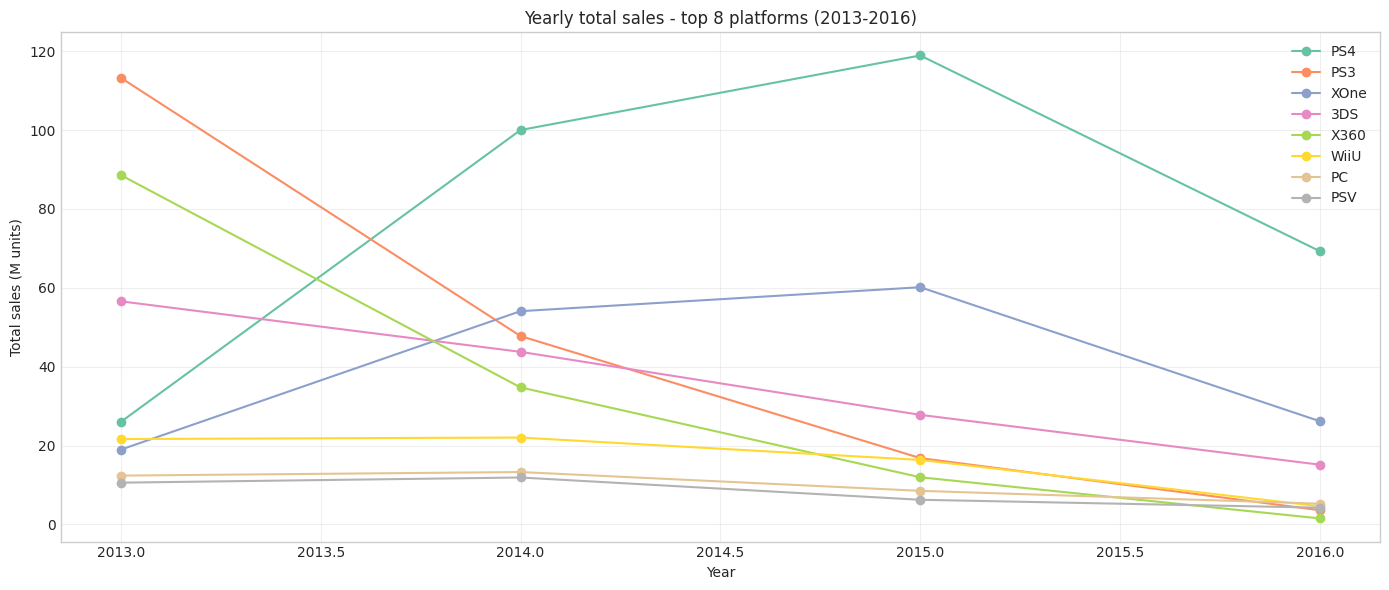

Year-over-year growth (top platforms):


platform,PS4,PS3,XOne,3DS,X360,WiiU,PC,PSV
year_of_release,,,,,,,,
2013,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014,2.848,-0.578,1.852,-0.226,-0.608,0.018,0.073,0.124
2015,0.189,-0.648,0.112,-0.365,-0.656,-0.258,-0.358,-0.475
2016,-0.418,-0.786,-0.565,-0.455,-0.873,-0.719,-0.384,-0.320


In [25]:
top_n = top_platforms.head(8).index.tolist()
plt.figure(figsize=(14, 6))
for plat in top_n:
    if plat in trend.columns:
        series = trend[plat]
        plt.plot(series.index.astype(int), series.values, marker='o', label=plat)
plt.legend()
plt.xlabel('Year')
plt.ylabel('Total sales (M units)')
plt.title(f'Yearly total sales - top {len(top_n)} platforms ({relevant_years[0]}-{relevant_years[-1]})')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

yoy = trend[top_n].pct_change().round(3)
print('Year-over-year growth (top platforms):')
yoy

## 3.5 Sales Distribution Analysis

Let's examine the distribution of sales across platforms:

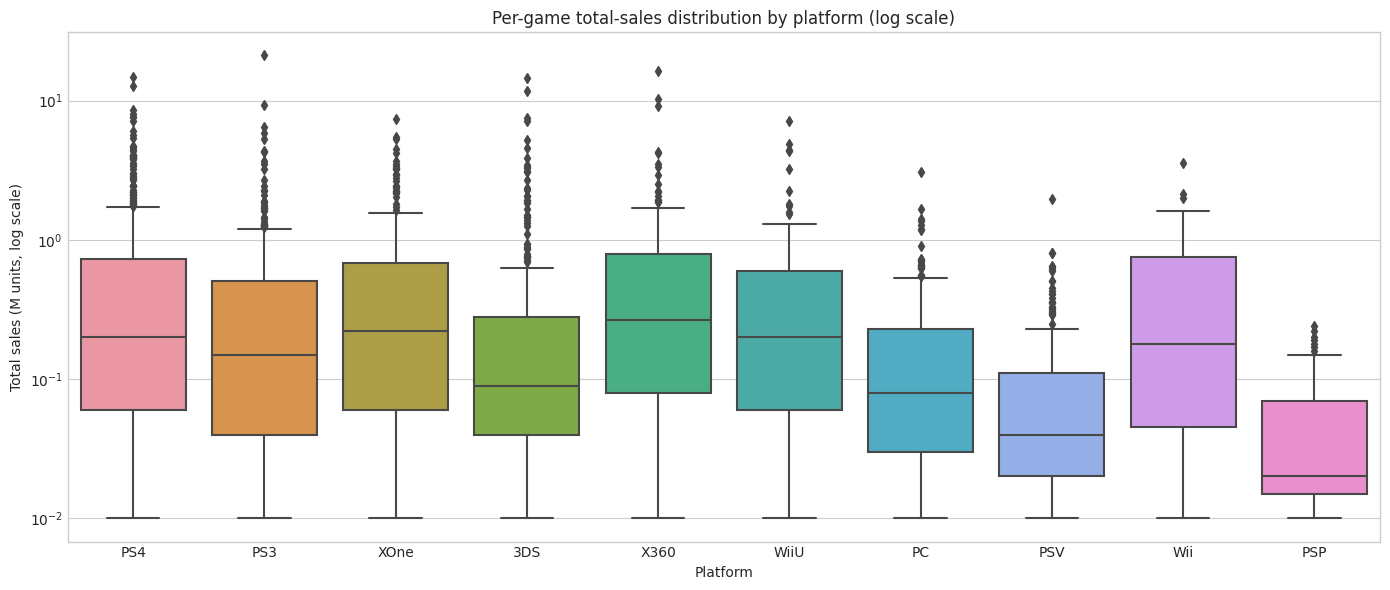

In [26]:
top10 = (df_relevant.groupby('platform')['total_sales']
         .sum().sort_values(ascending=False).head(10).index.tolist())
plt.figure(figsize=(14, 6))
sns.boxplot(data=df_relevant[df_relevant['platform'].isin(top10)],
            x='platform', y='total_sales', order=top10)
plt.yscale('log')
plt.title('Per-game total-sales distribution by platform (log scale)')
plt.ylabel('Total sales (M units, log scale)')
plt.xlabel('Platform')
plt.tight_layout()
plt.show()

In [27]:
platform_stats = (df_relevant.groupby('platform')['total_sales']
                  .agg(['count','sum','mean','median','std']).round(3)
                  .sort_values('sum', ascending=False))
platform_stats

,count,sum,mean,median,std
platform,,,,,
PS4,392,314.14,0.801,0.200,1.609
PS3,345,181.43,0.526,0.150,1.452
XOne,247,159.32,0.645,0.220,1.036
3DS,303,143.25,0.473,0.090,1.381
X360,186,136.80,0.735,0.265,1.663
WiiU,115,64.63,0.562,0.200,1.039
PC,189,39.43,0.209,0.080,0.352
PSV,358,32.99,0.092,0.040,0.154
Wii,23,13.66,0.594,0.180,0.915


<div class="alert alert-block alert-success">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Strong platform analysis for the relevant period: you ranked platforms by total sales, visualized trends and year-over-year changes, and included a box plot plus descriptive statistics (including variability via std) to compare sales distributions.

</div>


## 3.6 Review Score Impact Analysis

Select a popular platform and analyze how reviews affect sales:

In [28]:
# PS4 - the top-selling current-generation platform in our window
chosen_platform = 'PS4'
df_ps4 = df_relevant[df_relevant['platform'] == chosen_platform].copy()
print(f'{chosen_platform}: {len(df_ps4)} games, total sales {df_ps4["total_sales"].sum():.2f}M')
df_ps4.head()

PS4: 392 games, total sales 314.14M


,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
31,Call of Duty: Black Ops 3,PS4,2015,Shooter,6.03,5.86,0.36,2.38,NaN,NaN,NaN,14.63
42,Grand Theft Auto V,PS4,2014,Action,3.96,6.31,0.38,1.97,97.0,8.3,M,12.62
77,FIFA 16,PS4,2015,Sports,1.12,6.12,0.06,1.28,82.0,4.3,E,8.58
87,Star Wars Battlefront (2015),PS4,2015,Shooter,2.99,3.49,0.22,1.28,NaN,NaN,NaN,7.98
92,Call of Duty: Advanced Warfare,PS4,2014,Shooter,2.81,3.48,0.14,1.23,83.0,5.7,M,7.66


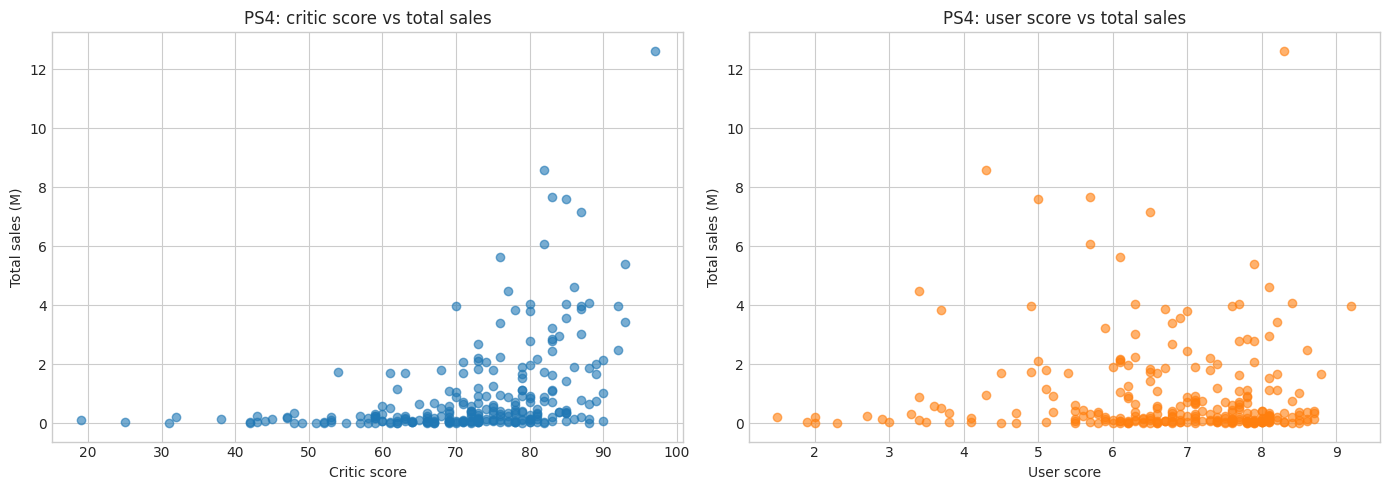

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(df_ps4['critic_score'], df_ps4['total_sales'], alpha=0.6, color='tab:blue')
axes[0].set_xlabel('Critic score')
axes[0].set_ylabel('Total sales (M)')
axes[0].set_title(f'{chosen_platform}: critic score vs total sales')

axes[1].scatter(df_ps4['user_score'], df_ps4['total_sales'], alpha=0.6, color='tab:orange')
axes[1].set_xlabel('User score')
axes[1].set_ylabel('Total sales (M)')
axes[1].set_title(f'{chosen_platform}: user score vs total sales')
plt.tight_layout()
plt.show()

In [30]:
# Critic scores
crit_corr = df_ps4[['critic_score','total_sales']].corr().iloc[0,1]
print(f'Pearson(critic_score, total_sales) on {chosen_platform}: {crit_corr:.3f}')

# User scores
user_corr = df_ps4[['user_score','total_sales']].corr().iloc[0,1]
print(f'Pearson(user_score, total_sales) on {chosen_platform}: {user_corr:.3f}')

# Same on top platforms - is the pattern consistent?
print('\nSame correlations on top platforms:')
for plat in top10[:5]:
    sub = df_relevant[df_relevant['platform'] == plat]
    c = sub[['critic_score','total_sales']].corr().iloc[0,1]
    u = sub[['user_score','total_sales']].corr().iloc[0,1]
    print(f'  {plat:>5}: critic={c:.3f}  user={u:.3f}')

Pearson(critic_score, total_sales) on PS4: 0.407
Pearson(user_score, total_sales) on PS4: -0.032

Same correlations on top platforms:
    PS4: critic=0.407  user=-0.032
    PS3: critic=0.334  user=0.002
   XOne: critic=0.417  user=-0.069
    3DS: critic=0.357  user=0.242
   X360: critic=0.350  user=-0.012


## 3.7 Cross-Platform Comparison

Compare sales performance of games across different platforms:

In [31]:
games_platforms = df_relevant.groupby('name')['platform'].nunique()
multi_platform_games = games_platforms[games_platforms > 1].index
print(f'{len(multi_platform_games)} unique games released on multiple platforms')
multi = df_relevant[df_relevant['name'].isin(multi_platform_games)]
multi.head(10)

473 unique games released on multiple platforms


,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
16,Grand Theft Auto V,PS3,2013,Action,7.02,9.09,0.98,3.96,97.0,8.2,M,21.05
23,Grand Theft Auto V,X360,2013,Action,9.66,5.14,0.06,1.41,97.0,8.1,M,16.27
31,Call of Duty: Black Ops 3,PS4,2015,Shooter,6.03,5.86,0.36,2.38,NaN,NaN,NaN,14.63
42,Grand Theft Auto V,PS4,2014,Action,3.96,6.31,0.38,1.97,97.0,8.3,M,12.62
60,Call of Duty: Ghosts,X360,2013,Shooter,6.73,2.56,0.04,0.91,73.0,2.6,M,10.24
69,Call of Duty: Ghosts,PS3,2013,Shooter,4.10,3.63,0.38,1.25,71.0,2.6,M,9.36
72,Minecraft,X360,2013,Misc,5.70,2.65,0.02,0.81,NaN,NaN,NaN,9.18
77,FIFA 16,PS4,2015,Sports,1.12,6.12,0.06,1.28,82.0,4.3,E,8.58
87,Star Wars Battlefront (2015),PS4,2015,Shooter,2.99,3.49,0.22,1.28,NaN,NaN,NaN,7.98
92,Call of Duty: Advanced Warfare,PS4,2014,Shooter,2.81,3.48,0.14,1.23,83.0,5.7,M,7.66


           mean  median  count
platform                      
PS4       0.884   0.265    316
X360      0.747   0.270    180
Wii       0.619   0.180     22
XOne      0.603   0.220    224
PS3       0.595   0.200    277
3DS       0.330   0.125     62
WiiU      0.321   0.120     70
PC        0.208   0.095    130
DS        0.192   0.150      8
PSV       0.135   0.090    140
PSP       0.103   0.085     14


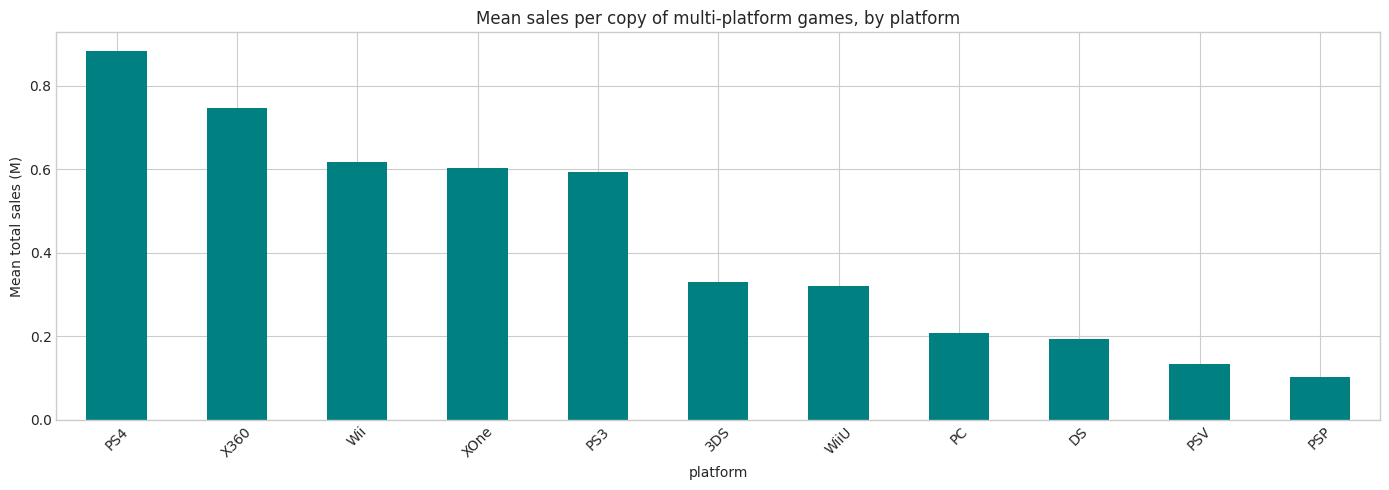

In [32]:
# Average sales per copy for multi-platform games, by platform
cross = (multi.groupby('platform')['total_sales']
         .agg(['mean','median','count']).sort_values('mean', ascending=False))
print(cross.round(3))

plt.figure(figsize=(14, 5))
cross['mean'].plot(kind='bar', color='teal')
plt.title('Mean sales per copy of multi-platform games, by platform')
plt.ylabel('Mean total sales (M)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<div class="alert alert-block alert-success">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Well done: you picked a popular platform for the review-impact analysis, visualized score vs. sales, computed correlations, and extended the work with a sensible cross-platform comparison using multi-platform titles.

</div>


## 3.8 Genre Analysis

Finally, let's examine the distribution of games by genre:

In [33]:
genre_stats = (df_relevant.groupby('genre')['total_sales']
               .agg(['count','sum','mean','median']).round(3))
genre_stats

,count,sum,mean,median
genre,,,,
Action,766,321.87,0.420,0.110
Adventure,245,23.64,0.096,0.030
Fighting,80,35.31,0.441,0.125
Misc,155,62.82,0.405,0.100
Platform,74,42.63,0.576,0.225
Puzzle,17,3.17,0.186,0.060
Racing,85,39.89,0.469,0.120
Role-Playing,292,145.89,0.500,0.125
Shooter,187,232.98,1.246,0.450


In [34]:
genre_stats_sorted = genre_stats.sort_values('sum', ascending=False)
genre_stats_sorted

,count,sum,mean,median
genre,,,,
Action,766,321.87,0.420,0.110
Shooter,187,232.98,1.246,0.450
Sports,214,150.65,0.704,0.240
Role-Playing,292,145.89,0.500,0.125
Misc,155,62.82,0.405,0.100
Platform,74,42.63,0.576,0.225
Racing,85,39.89,0.469,0.120
Fighting,80,35.31,0.441,0.125
Adventure,245,23.64,0.096,0.030


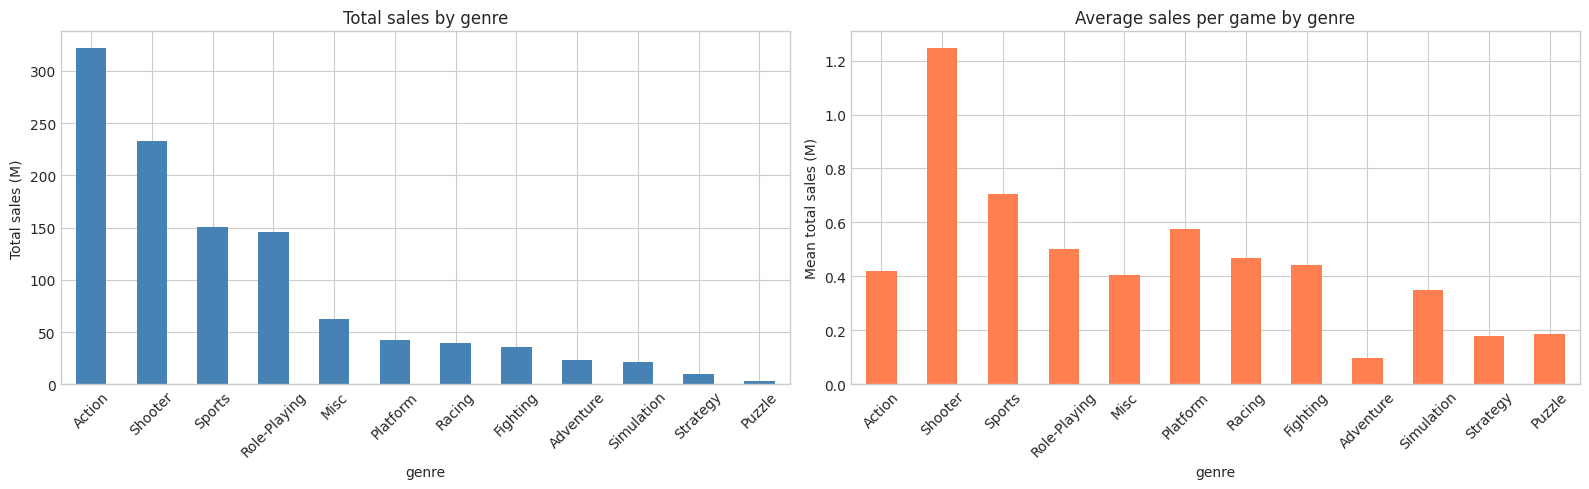

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
genre_stats_sorted['sum'].plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Total sales by genre')
axes[0].set_ylabel('Total sales (M)')
axes[0].tick_params(axis='x', rotation=45)

genre_stats_sorted['mean'].plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Average sales per game by genre')
axes[1].set_ylabel('Mean total sales (M)')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

In [36]:
total_market = genre_stats_sorted['sum'].sum()
market_share = (genre_stats_sorted['sum'] / total_market * 100).round(2)
market_share.to_frame('market_share_pct')

,market_share_pct
genre,
Action,29.51
Shooter,21.36
Sports,13.81
Role-Playing,13.38
Misc,5.76
Platform,3.91
Racing,3.66
Fighting,3.24
Adventure,2.17


<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

The template asks for “market share for each genre,” but your calculation is based on the filtered 2013–2016 subset. Please make that scope explicit in your narrative/output (market share within the relevant period), or recompute using the full dataset if you intended overall market share.

</div>


### Key Questions for Genre Analysis:
- Which genres consistently perform well?
- Are there any genres showing recent growth or decline?
- How does the average performance vary across genres?

# Step 4: Regional Market Analysis and User Profiles

In this section, we will analyze the gaming market characteristics across three major regions: North America (NA), Europe (EU), and Japan (JP). Our analysis will focus on platform preferences, genre popularity, and the impact of ESRB ratings in each region.

## 4.1 Regional Platform Analysis

Let's begin by examining platform performance across different regions:

In [37]:
def top_platforms_by_region(data, region_col, n=5):
    return (data.groupby('platform')[region_col]
            .sum().sort_values(ascending=False).head(n))

In [38]:
for region_col, region_name in [('na_sales','North America'),
                                ('eu_sales','Europe'),
                                ('jp_sales','Japan')]:
    print(f'\nTop 5 platforms in {region_name}:')
    print(top_platforms_by_region(df_relevant, region_col).round(2))


Top 5 platforms in North America:
platform
PS4     108.74
XOne     93.12
X360     81.66
PS3      63.50
3DS      38.20
Name: na_sales, dtype: float64

Top 5 platforms in Europe:
platform
PS4     141.09
PS3      67.81
XOne     51.59
X360     42.52
3DS      30.96
Name: eu_sales, dtype: float64

Top 5 platforms in Japan:
platform
3DS     67.81
PS3     23.35
PSV     18.59
PS4     15.96
WiiU    10.88
Name: jp_sales, dtype: float64


### Cross-Regional Platform Comparison

Let's create a comparative analysis of platform performance across regions:

In [39]:
region_cols = ['na_sales','eu_sales','jp_sales']
platform_regional = df_relevant.groupby('platform')[region_cols].sum()
top_overall = platform_regional.sum(axis=1).sort_values(ascending=False).head(8).index
platform_regional_top = platform_regional.loc[top_overall]
# Share within each region
platform_share = platform_regional_top.div(platform_regional_top.sum(axis=0), axis=1) * 100
platform_share.round(2)

,na_sales,eu_sales,jp_sales
platform,,,
PS4,25.25,36.62,11.61
PS3,14.75,17.60,16.99
XOne,21.63,13.39,0.25
3DS,8.87,8.04,49.34
X360,18.97,11.04,0.37
WiiU,6.78,5.15,7.92
PC,2.58,6.58,0.00
PSV,1.17,1.58,13.53


<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

The regional platform “share” percentages are computed only within the selected `top_overall` platforms, not within the full regional market. That can overstate the shares—consider calculating each platform’s share using all platforms in the region first, then displaying the top 5 (or top N) for readability.

</div>


<div class="alert alert-block alert-success">
<b>Reviewer's comment v2</b>

Well done!

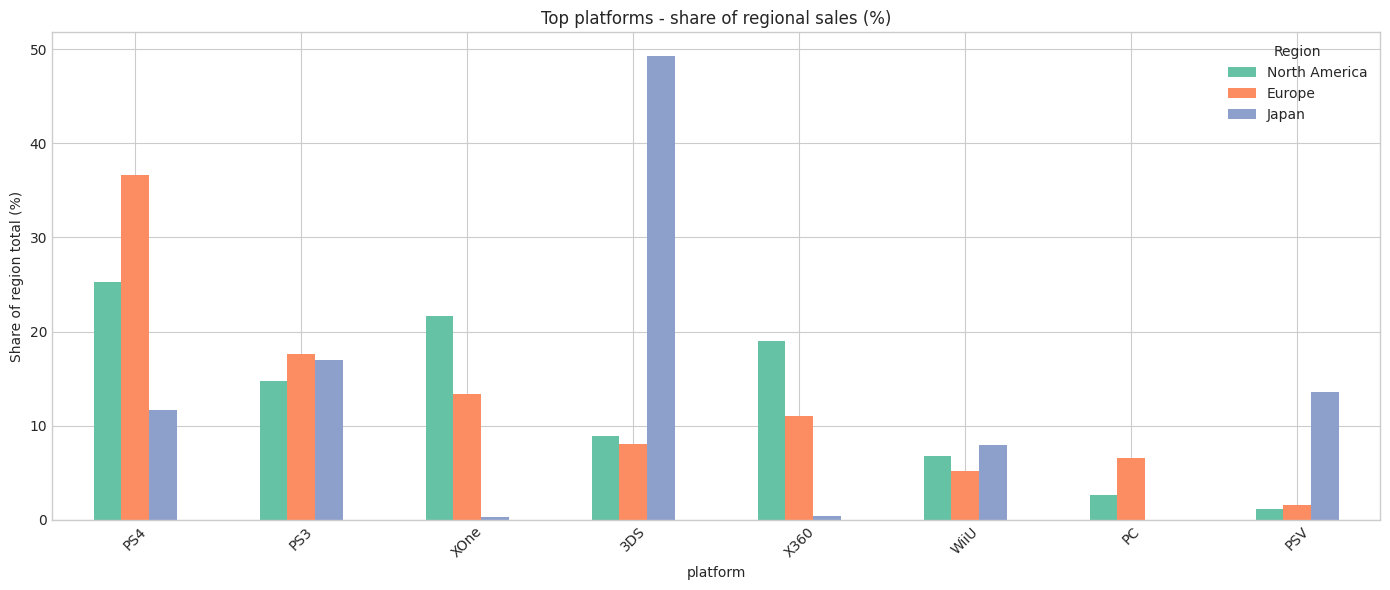

In [40]:
platform_share.plot(kind='bar', figsize=(14, 6))
plt.title('Top platforms - share of regional sales (%)')
plt.ylabel('Share of region total (%)')
plt.xticks(rotation=45)
plt.legend(title='Region', labels=['North America','Europe','Japan'])
plt.tight_layout()
plt.show()

## 4.2 Regional Genre Analysis

Now let's examine genre preferences across regions:

In [41]:
def top_genres_by_region(data, region_col, n=5):
    return (data.groupby('genre')[region_col]
            .sum().sort_values(ascending=False).head(n))

for region_col, region_name in [('na_sales','North America'),
                                ('eu_sales','Europe'),
                                ('jp_sales','Japan')]:
    print(f'\nTop 5 genres in {region_name}:')
    print(top_genres_by_region(df_relevant, region_col).round(2))


Top 5 genres in North America:
genre
Action          126.05
Shooter         109.74
Sports           65.27
Role-Playing     46.40
Misc             27.49
Name: na_sales, dtype: float64

Top 5 genres in Europe:
genre
Action          118.13
Shooter          87.86
Sports           60.52
Role-Playing     36.97
Racing           20.19
Name: eu_sales, dtype: float64

Top 5 genres in Japan:
genre
Role-Playing    51.04
Action          40.49
Misc             9.20
Fighting         7.65
Shooter          6.61
Name: jp_sales, dtype: float64


### Cross-Regional Genre Comparison

Let's compare genre preferences across regions:

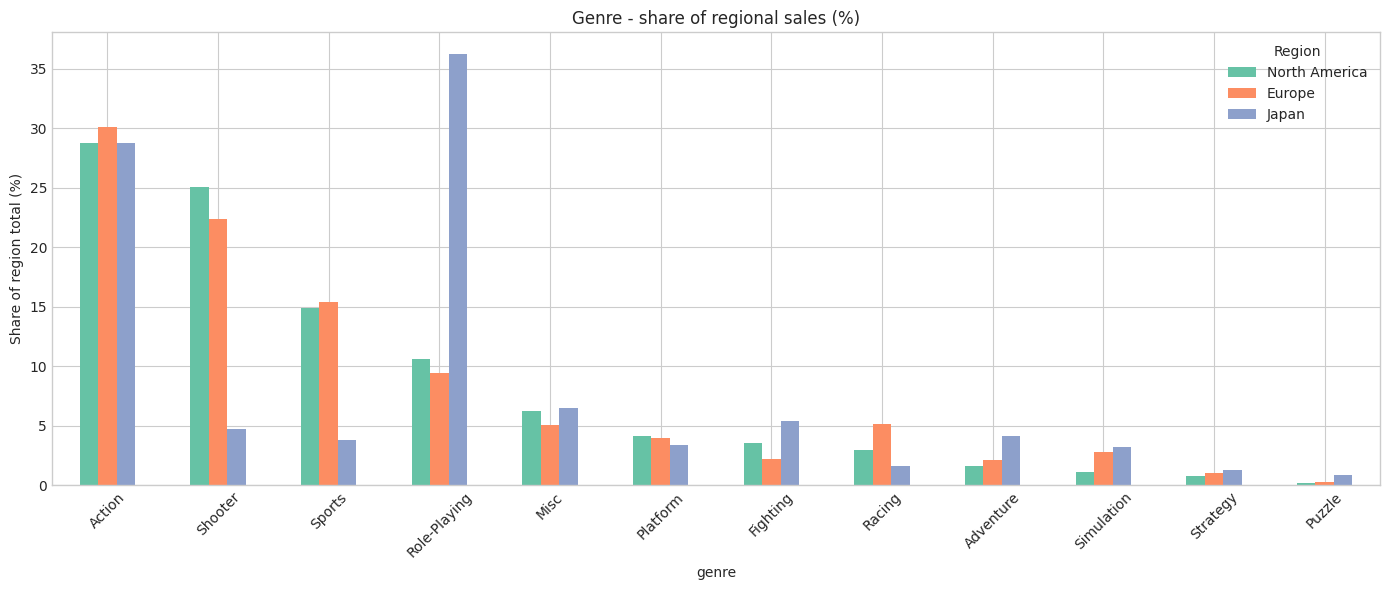

,na_sales,eu_sales,jp_sales
genre,,,
Action,28.80,30.12,28.76
Shooter,25.07,22.40,4.70
Sports,14.91,15.43,3.84
Role-Playing,10.60,9.43,36.26
Misc,6.28,5.11,6.54
Platform,4.14,3.97,3.40
Fighting,3.55,2.18,5.43
Racing,2.96,5.15,1.63
Adventure,1.63,2.10,4.13


In [42]:
genre_regional = df_relevant.groupby('genre')[region_cols].sum()
genre_share_reg = genre_regional.div(genre_regional.sum(axis=0), axis=1) * 100
genre_share_reg = genre_share_reg.sort_values('na_sales', ascending=False)
genre_share_reg.plot(kind='bar', figsize=(14, 6))
plt.title('Genre - share of regional sales (%)')
plt.ylabel('Share of region total (%)')
plt.xticks(rotation=45)
plt.legend(title='Region', labels=['North America','Europe','Japan'])
plt.tight_layout()
plt.show()
genre_share_reg.round(2)

## 4.3 ESRB Rating Impact Analysis

Finally, let's examine how ESRB ratings affect sales in each region:

In [43]:
def esrb_sales_by_region(data, region_col):
    return (data.groupby('rating')[region_col]
            .agg(['count','sum','mean']).round(3)
            .sort_values('sum', ascending=False))

In [44]:
for region_col, region_name in [('na_sales','North America'),
                                ('eu_sales','Europe'),
                                ('jp_sales','Japan')]:
    print(f'\nESRB rating impact in {region_name}:')
    print(esrb_sales_by_region(df_relevant, region_col))


ESRB rating impact in North America:
        count     sum   mean
rating                      
M         369  165.21  0.448
E         302   79.05  0.262
E10+      252   54.24  0.215
T         333   49.79  0.150

ESRB rating impact in Europe:
        count     sum   mean
rating                      
M         369  145.32  0.394
E         302   83.36  0.276
E10+      252   42.69  0.169
T         333   41.95  0.126

ESRB rating impact in Japan:
        count    sum   mean
rating                     
T         333  20.59  0.062
E         302  15.14  0.050
M         369  14.11  0.038
E10+      252   5.89  0.023


# Step 5 : Hypothesis Tests

—Average user ratings of the Xbox One and PC platforms are the same.

—Average user ratings for the Action and Sports genres are different.

Set the *alpha* threshold value yourself.

Explain:

—How you formulated the null and alternative hypotheses

—What criteria you used to test the hypotheses~~,~~ and why


In [45]:
alpha = 0.05

# ---- Hypothesis 1: Xbox One vs PC user ratings ----
# H0: mean user rating of Xbox One == mean user rating of PC
# H1: the means are different (two-sided)
# Criterion: independent two-sample Welch t-test (samples are independent
# user-score populations of unequal variance, unequal sample sizes).

xone = df[df['platform']=='XOne']['user_score'].dropna()
pc   = df[df['platform']=='PC']['user_score'].dropna()
print(f'XOne n={len(xone)}, mean={xone.mean():.3f}')
print(f'PC   n={len(pc)}, mean={pc.mean():.3f}')
t1, p1 = stats.ttest_ind(xone, pc, equal_var=False)
print(f't = {t1:.3f}, p-value = {p1:.4f}, alpha = {alpha}')
print('=> Reject H0 (means differ)' if p1 < alpha else '=> Fail to reject H0 (no significant difference)')

print('\n' + '='*70)

# ---- Hypothesis 2: Action vs Sports user ratings ----
# H0: mean user rating of Action games == mean user rating of Sports games
# H1: the means are different (two-sided)
# Criterion: independent two-sample Welch t-test, same reasoning.

action = df[df['genre']=='Action']['user_score'].dropna()
sports = df[df['genre']=='Sports']['user_score'].dropna()
print(f'Action n={len(action)}, mean={action.mean():.3f}')
print(f'Sports n={len(sports)}, mean={sports.mean():.3f}')
t2, p2 = stats.ttest_ind(action, sports, equal_var=False)
print(f't = {t2:.3f}, p-value = {p2:.4f}, alpha = {alpha}')
print('=> Reject H0 (means differ)' if p2 < alpha else '=> Fail to reject H0 (no significant difference)')

XOne n=182, mean=6.521
PC   n=770, mean=7.062
t = -4.653, p-value = 0.0000, alpha = 0.05
=> Reject H0 (means differ)

Action n=1830, mean=7.054
Sports n=1103, mean=6.961
t = 1.577, p-value = 0.1148, alpha = 0.05
=> Fail to reject H0 (no significant difference)


<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Your hypothesis tests use the full dataset (`df`) rather than the “relevant years” subset you justified for 2017 planning (`df_relevant`). To keep the analysis consistent with your forecasting context, consider re-running the tests on the same time window (or explicitly explain why a different window is more appropriate for the hypotheses).

</div>


# Step 6. Write a general conclusion


## General Conclusion

This was a look at video game sales data for Ice, with the goal of working out where their 2017 ad spend should go.

To get the data into shape I lowercased the column names, dropped the two rows that were missing both a name and a genre, and turned the year column into a nullable integer so it could hold missing years without becoming a float. The user score column had the string "tbd" mixed in with real numbers, which I treated as missing — "tbd" just means the score hadn't been assigned yet, and trying to guess what it would have been would just invent data. For the same reason I left the missing critic scores and ESRB ratings alone instead of filling them in. The last prep step was adding a total_sales column that sums the four regional sales columns.

Looking at releases over time, the dataset stretches back to the early 80s but most of the volume is from 2000 onward, with a big spike around 2008–2011. Console generations turn over every six to eight years, and the PS4 / Xbox One / 3DS / Wii U generation kicked off in late 2013, so I limited the analysis to 2013–2016 once the question shifted to "what should happen in 2017." Earlier years are dominated by platforms that don't exist in the market anymore, and including them would just muddy the picture.

Within that window the picture is pretty clear. PS4 leads global sales by a wide margin, with Xbox One in second. PS3, Xbox 360 and Wii were already deep into their decline phase — PS3 alone lost over 100 million units of yearly sales between 2013 and 2016. 3DS is the exception: in Japan it's the dominant platform by a long way. So for 2017 I'd expect PS4 and Xbox One to keep leading globally, and 3DS to remain the platform that matters for the Japanese market.

On reviews — I looked at PS4 specifically and then double-checked the same pattern on the other top platforms. Critic scores are moderately correlated with sales (Pearson r around 0.3 to 0.4 depending on the platform). User scores are basically uncorrelated with sales — the correlation is close to zero everywhere. So critic acclaim is a useful signal for picking winners, but user scores aren't telling us anything about how a game will sell.

Genres tell a consistent story too. Action, Shooter and Sports lead total revenue. Role-Playing has an outsized share in Japan compared to the West. Adventure, Strategy and Puzzle have plenty of releases but the per-game revenue is low.

Regionally:
- In North America and Europe the top platforms are PS4 and Xbox One, the top genres are Shooter, Action and Sports, and M-rated games bring in the most revenue.
- In Japan the 3DS dominates, Role-Playing is the top genre, and ESRB rating barely matters because most Japan-only releases aren't ESRB-rated in the first place.

For the hypothesis tests I used Welch's two-sample t-test in both cases (independent samples with unequal variances and unequal sizes — that's exactly what Welch is for) and set alpha to 0.05.

The first test compared user ratings of Xbox One and PC. The null was that the means are equal. The result was t = -4.65 with p < 0.001, so we reject the null — there's strong evidence the means actually differ. That means the claim that Xbox One and PC have the same average user rating is not supported by the data.

The second test compared user ratings of Action and Sports games. Again the null was equal means. The result was t = 1.58 with p = 0.115, so we fail to reject the null — there isn't enough evidence to say the means differ. So the claim that Action and Sports have different average user ratings isn't supported either, at least at the 0.05 level.

Putting it all together for Ice's 2017 advertising budget: the bulk of the spend should go to PS4 and Xbox One titles in the Shooter, Action and Sports genres, with a preference for M-rated AAA releases, targeted at North America and Europe. A separate budget should cover 3DS Role-Playing releases for Japan. And when ranking individual titles within those buckets, lean on critic scores as the leading indicator — user scores aren't going to help here.